<a href="https://colab.research.google.com/github/jaimecuesta92/DS-Challenge3/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Extracción del Archivo Tratado**

In [1]:
import pandas as pd


datos = pd.read_csv('/content/drive/MyDrive/Data_Science/Challenge_3/datos_normalize.csv')
datos.head()

,ID_Cliente,Cancelo,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [2]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Cancelo                  7043 non-null   int64  
 2   Genero                   7043 non-null   object 
 3   Adulto_Mayor             7043 non-null   int64  
 4   Socio                    7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Meses_Permanencia        7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Multiples_Lineas         7043 non-null   int64  
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   int64  
 11  Respaldo_Online          7043 non-null   int64  
 12  Proteccion_Dispositivo   7043 non-null   int64  
 13  Soporte_Tecnico          7043 non-null   int64  
 14  Streaming_TV            

In [3]:
# 1. Intentamos convertir a numérico, los que no se puedan se volverán NaN (nulos técnicos)
datos['Cargos_Totales_Aux'] = pd.to_numeric(datos['Cargos_Totales'], errors='coerce')

# 2. Filtramos para ver SOLO las filas donde la conversión falló o el dato es nulo
errores_cargos = datos[datos['Cargos_Totales_Aux'].isna()]

# 3. Mostramos esas filas y específicamente la columna 'Meses_Permanencia'
print(f"Se encontraron {len(errores_cargos)} registros problemáticos.")
print("\n--- Muestra de los datos que no son números en Cargos_Totales ---")
print(errores_cargos[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']])

Se encontraron 11 registros problemáticos.

--- Muestra de los datos que no son números en Cargos_Totales ---
      Meses_Permanencia  Cargos_Mensuales  Cargos_Totales
945                   0             56.05             NaN
1731                  0             20.00             NaN
1906                  0             61.90             NaN
2025                  0             19.70             NaN
2176                  0             20.25             NaN
2250                  0             25.35             NaN
2855                  0             73.35             NaN
3052                  0             25.75             NaN
3118                  0             52.55             NaN
4054                  0             80.85             NaN
5433                  0             19.85             NaN


In [4]:
# 1. Eliminamos esas 11 filas con NaN en Cargos_Totales
datos = datos.dropna(subset=['Cargos_Totales'])

# 2. Eliminamos ID_Cliente (no ayuda a predecir, es solo un nombre)
datos = datos.drop('ID_Cliente', axis=1)

# 3. Verificamos que ya no existan Nulos
print("Conteo de nulos final:")
print(datos.isnull().sum().sum())

Conteo de nulos final:
0


In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cancelo                  7032 non-null   int64  
 1   Genero                   7032 non-null   object 
 2   Adulto_Mayor             7032 non-null   int64  
 3   Socio                    7032 non-null   int64  
 4   Dependientes             7032 non-null   int64  
 5   Meses_Permanencia        7032 non-null   int64  
 6   Servicio_Telefonico      7032 non-null   int64  
 7   Multiples_Lineas         7032 non-null   int64  
 8   Servicio_Internet        7032 non-null   object 
 9   Seguridad_Online         7032 non-null   int64  
 10  Respaldo_Online          7032 non-null   int64  
 11  Proteccion_Dispositivo   7032 non-null   int64  
 12  Soporte_Tecnico          7032 non-null   int64  
 13  Streaming_TV             7032 non-null   int64  
 14  Streaming_Peliculas      7032

In [6]:
# Eliminamos las columnas redundantes o auxiliares
columnas_a_borrar = ['Cargos_Totales_Aux', 'Cuentas_Diarias','Genero']
datos = datos.drop(columns=columnas_a_borrar)

# Verificamos el resultado
print(f"Columnas restantes: {len(datos.columns)}")
print(datos.columns.tolist())

Columnas restantes: 19
['Cancelo', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales']


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cancelo                  7032 non-null   int64  
 1   Adulto_Mayor             7032 non-null   int64  
 2   Socio                    7032 non-null   int64  
 3   Dependientes             7032 non-null   int64  
 4   Meses_Permanencia        7032 non-null   int64  
 5   Servicio_Telefonico      7032 non-null   int64  
 6   Multiples_Lineas         7032 non-null   int64  
 7   Servicio_Internet        7032 non-null   object 
 8   Seguridad_Online         7032 non-null   int64  
 9   Respaldo_Online          7032 non-null   int64  
 10  Proteccion_Dispositivo   7032 non-null   int64  
 11  Soporte_Tecnico          7032 non-null   int64  
 12  Streaming_TV             7032 non-null   int64  
 13  Streaming_Peliculas      7032 non-null   int64  
 14  Tipo_Contrato            7032

#**Análisis de Correlación**

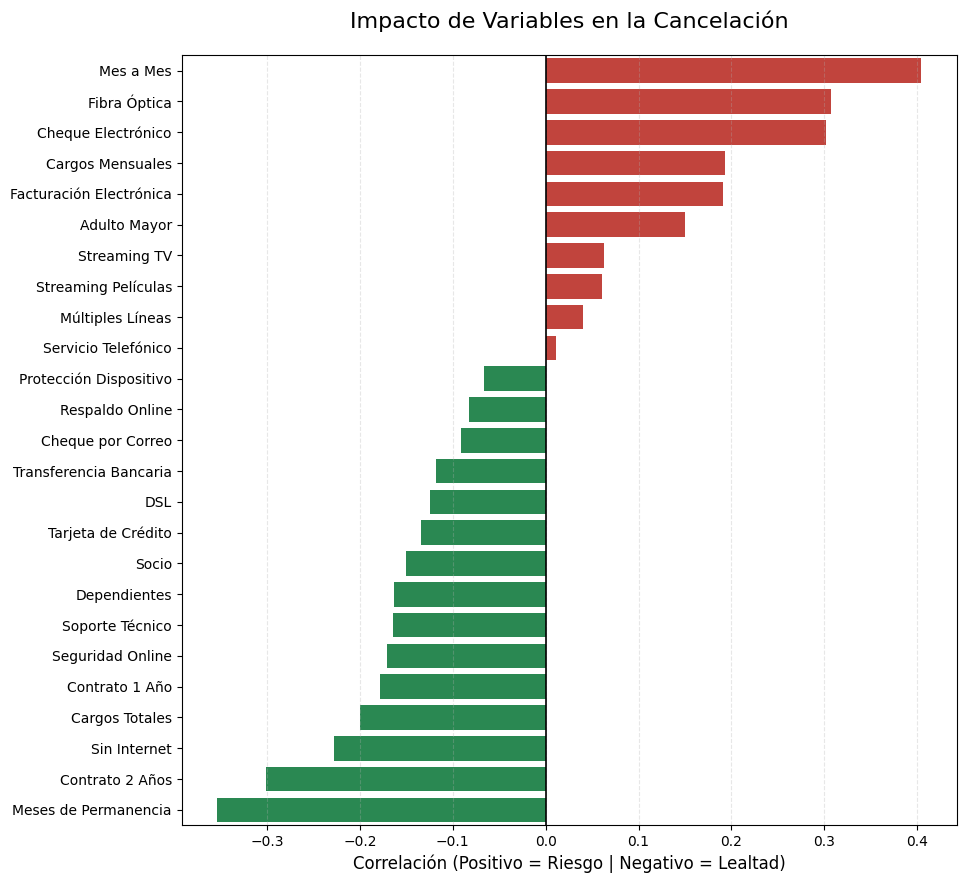

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Diccionario con nombres directos (sin categorías extra)
mapeo_nombres = {
    'Tipo_Contrato_Month-to-month': 'Mes a Mes',
    'Servicio_internet_Fiber optic': 'Fibra Óptica',
    'Servicio_Internet_Fiber optic': 'Fibra Óptica', # Doble entrada por si la 'i' es mayúscula
    'Metodo_Pago_Electronic check': 'Cheque Electrónico',
    'Cargos_Mensuales': 'Cargos Mensuales',
    'Facturacion_Electronica': 'Facturación Electrónica',
    'Adulto_Mayor': 'Adulto Mayor',
    'Streaming_TV': 'Streaming TV',
    'Streaming_Peliculas': 'Streaming Películas',
    'Multiples_Lineas': 'Múltiples Líneas',
    'Servicio_Telefonico': 'Servicio Telefónico',
    'Proteccion_Dispositivo': 'Protección Dispositivo',
    'Respaldo_Online': 'Respaldo Online',
    'Metodo_Pago_Mailed check': 'Cheque por Correo',
    'Metodo_Pago_Bank transfer (automatic)': 'Transferencia Bancaria',
    'Servicio_Internet_DSL': 'DSL',
    'Metodo_Pago_Credit card (automatic)': 'Tarjeta de Crédito',
    'Socio': 'Socio',
    'Dependientes': 'Dependientes',
    'Soporte_Tecnico': 'Soporte Técnico',
    'Seguridad_Online': 'Seguridad Online',
    'Tipo_Contrato_One year': 'Contrato 1 Año',
    'Cargos_Totales': 'Cargos Totales',
    'Servicio_Internet_No': 'Sin Internet',
    'Tipo_Contrato_Two year': 'Contrato 2 Años',
    'Meses_Permanencia': 'Meses de Permanencia'
}

# 2. Obtenemos la correlación
correlacion_churn = datos_final.corr()['Cancelo'].sort_values(ascending=False).drop('Cancelo')

# 3. Aplicamos el mapeo (usamos .strip() por si hay espacios invisibles en los nombres)
nombres_limpios = [mapeo_nombres.get(nombre.strip(), nombre) for nombre in correlacion_churn.index]

# 4. Lógica de colores (Rojo = Riesgo/Derecha, Verde = Lealtad/Izquierda)
colores = ['#d73027' if x > 0 else '#1a9850' for x in correlacion_churn.values]

# 5. Graficamos
plt.figure(figsize=(10, 10))
sns.barplot(
    x=correlacion_churn.values,
    y=nombres_limpios,
    hue=nombres_limpios,
    palette=colores,
    legend=False
)

plt.axvline(0, color='black', linewidth=1.2)
plt.title('Impacto de Variables en la Cancelación', fontsize=16, pad=20)
plt.xlabel('Correlación (Positivo = Riesgo | Negativo = Lealtad)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

#**Análisis Dirigido**

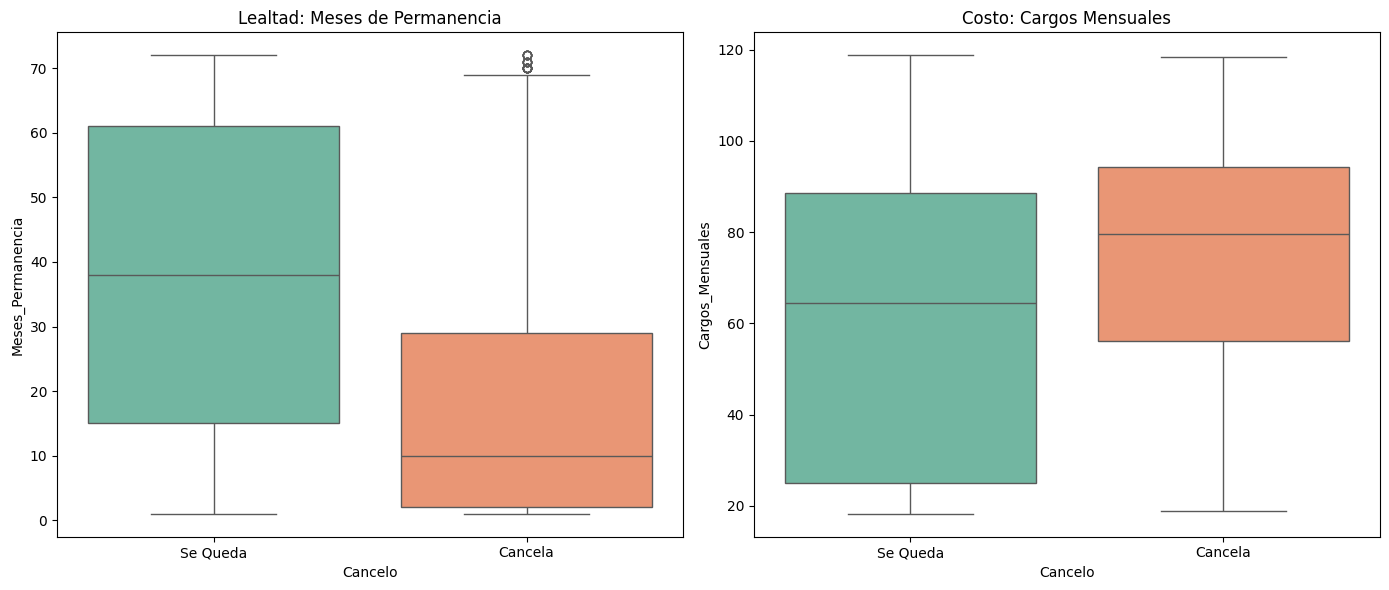

In [17]:
plt.figure(figsize=(14, 6))

# Subplot 1: Meses de Permanencia
plt.subplot(1, 2, 1)
sns.boxplot(
    x='Cancelo',
    y='Meses_Permanencia',
    data=datos,
    hue='Cancelo',
    palette='Set2',
    legend=False
)
plt.title('Lealtad: Meses de Permanencia')
plt.xticks([0, 1], ['Se Queda', 'Cancela'])

# Subplot 2: Cargos Mensuales
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Cancelo',
    y='Cargos_Mensuales',
    data=datos,
    hue='Cancelo',
    palette='Set2',
    legend=False
    )
plt.title('Costo: Cargos Mensuales')
plt.xticks([0, 1], ['Se Queda', 'Cancela'])

plt.tight_layout()
plt.show()

#**Encoding**

In [8]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# 1. Definimos las categóricas (sin Género ni ID)
categoricas = ['Servicio_Internet', 'Tipo_Contrato', 'Metodo_Pago']

# 2. Creamos el transformador (como en tu ejemplo)
one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    categoricas),
    remainder='passthrough'
)

# 3. Transformamos y reconstruimos el DataFrame
datos_transformados = one_hot_enc.fit_transform(datos)
datos_final = pd.DataFrame(datos_transformados, columns=one_hot_enc.get_feature_names_out())

# 4. Aseguramos que los nombres de las columnas sean limpios (quitar el prefijo 'remainder__')
datos_final.columns = [col.replace('remainder__', '').replace('onehotencoder__', '') for col in datos_final.columns]

datos_final.head()

,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Servicio_Internet_No,Tipo_Contrato_Month-to-month,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Bank transfer (automatic),Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check,...,Multiples_Lineas,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40


--- Distribución de la Clase Objetivo (Cancelo) ---
Clientes que se quedan (0): 5163 (73.42%)
Clientes que cancelan (1):  1869 (26.58%)


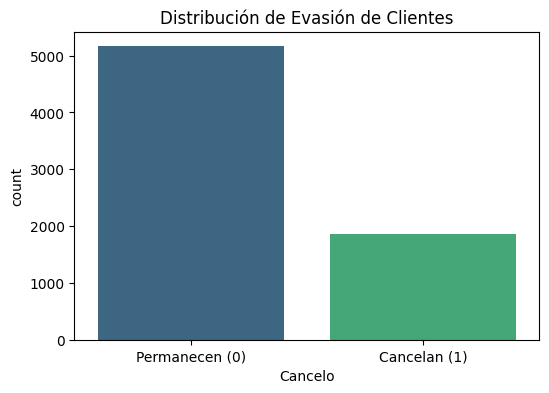

In [9]:
# 1. Contamos cuántos hay en cada categoría
conteo_clases = datos['Cancelo'].value_counts()

# 2. Calculamos el porcentaje
proporciones = datos['Cancelo'].value_counts(normalize=True) * 100

# 3. Mostramos los resultados
print("--- Distribución de la Clase Objetivo (Cancelo) ---")
print(f"Clientes que se quedan (0): {conteo_clases[0]} ({proporciones[0]:.2f}%)")
print(f"Clientes que cancelan (1):  {conteo_clases[1]} ({proporciones[1]:.2f}%)")

# 4. Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Cancelo', data=datos, hue='Cancelo', palette='viridis', legend=False)
plt.title('Distribución de Evasión de Clientes')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()

#**Separación de Datos y creación de modelo 1**
##**Regresión Logística con Pesos Balanceados**

In [10]:
# 1. Separamos las características (X) del objetivo (y)
X = datos_final.drop(['Cancelo'], axis=1)
y = datos_final['Cancelo']

Exactitud (Train): 0.8005
Exactitud (Val):   0.7960


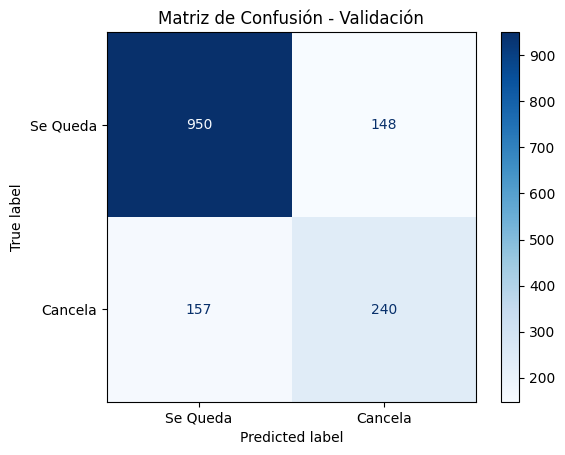

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Primera división: Separamos el 15% para el "Examen Final" (Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5)

# 2. Segunda división: Del resto (85%), sacamos el conjunto de Validación
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=5)

# 3. Entrenamos el Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42) # Probemos con profundidad 5 para evitar sobreajuste
modelo_arbol.fit(X_train, y_train)

# 4. Evaluamos exactitud
print(f'Exactitud (Train): {modelo_arbol.score(X_train, y_train):.4f}')
print(f'Exactitud (Val):   {modelo_arbol.score(X_val, y_val):.4f}')

# 5. Matriz de Confusión Visual
y_pred_val = modelo_arbol.predict(X_val)
matriz = confusion_matrix(y_val, y_pred_val)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Se Queda', 'Cancela'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Validación')
plt.show()

In [12]:
from sklearn.metrics import classification_report, average_precision_score

# 1. Obtenemos las probabilidades (necesarias para el Average Precision)
# Esto nos da la probabilidad de que cada cliente cancele
y_prob_val = modelo_arbol.predict_proba(X_val)[:, 1]

# 2. Calculamos el Average Precision Score
ap_score = average_precision_score(y_val, y_prob_val)

print(f"Average Precision Score: {ap_score:.4f}")
print("\n--- Reporte de Clasificación Detallado ---")
# Usamos y_pred_val que ya tenías de la celda anterior
print(classification_report(y_val, y_pred_val, target_names=['Se Queda', 'Cancela']))

Average Precision Score: 0.6242

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

    Se Queda       0.86      0.87      0.86      1098
     Cancela       0.62      0.60      0.61       397

    accuracy                           0.80      1495
   macro avg       0.74      0.73      0.74      1495
weighted avg       0.79      0.80      0.80      1495



In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definimos el modelo con balanceo para mejorar el Recall
modelo = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=5)

# 2. Usamos StratifiedKFold para mantener la proporción 73/27 en cada prueba
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# 3. Ejecutamos la validación cruzada con tus métricas
cv_resultados = cross_validate(modelo, X, y, cv=skf,
                               scoring=['accuracy', 'recall', 'precision', 'f1'])

# 4. Tu función de informe (ajustada para imprimir el promedio también)
def informe_metricas_profesional(resultados):
    print(f"{'Métrica':<20} | {'Promedio':<10} | {'Intervalo de Confianza (95%)'}")
    print("-" * 65)
    for metrica in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        media = resultados[metrica].mean()
        desvio_estandar = resultados[metrica].std()
        lim_inf = media - 2 * desvio_estandar
        lim_sup = min(media + 2 * desvio_estandar, 1.0)

        print(f"{metrica:<20} | {media:<10.4f} | [{lim_inf:.4f}, {lim_sup:.4f}]")

informe_metricas_profesional(cv_resultados)

Métrica              | Promedio   | Intervalo de Confianza (95%)
-----------------------------------------------------------------
test_accuracy        | 0.7358     | [0.7019, 0.7697]
test_recall          | 0.7747     | [0.7169, 0.8326]
test_precision       | 0.5028     | [0.4613, 0.5444]
test_f1              | 0.6094     | [0.5756, 0.6431]


In [14]:
from sklearn.preprocessing import StandardScaler

# 1. Identificamos las columnas numéricas originales
cols_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos (creamos una copia para no dañar los originales)
datos_escalados = datos_final.copy()
datos_escalados[cols_numericas] = scaler.fit_transform(datos_final[cols_numericas])

print("Datos estandarizados con éxito.")
datos_escalados[cols_numericas].head()

Datos estandarizados con éxito.


,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales
0,-0.954296,0.026652,-0.745607
1,-0.954296,-0.162819,-0.768063
2,-1.158016,0.302548,-0.883456
3,-0.791321,1.103642,-0.461240
4,-1.198760,0.634952,-0.889390


In [15]:
from sklearn.linear_model import LogisticRegression

# Usamos los datos escalados
X_esc = datos_escalados.drop(['Cancelo'], axis=1)
y_esc = datos_escalados['Cancelo']

# Definimos la Regresión Logística con balanceo
modelo_log = LogisticRegression(class_weight='balanced', random_state=5)

# Validación cruzada estratificada (mismo esquema que antes)
cv_log = cross_validate(modelo_log, X_esc, y_esc, cv=skf,
                        scoring=['accuracy', 'recall', 'precision', 'f1'])

print("--- RESULTADOS REGRESIÓN LOGÍSTICA (Estandarizada) ---")
informe_metricas_profesional(cv_log)

--- RESULTADOS REGRESIÓN LOGÍSTICA (Estandarizada) ---
Métrica              | Promedio   | Intervalo de Confianza (95%)
-----------------------------------------------------------------
test_accuracy        | 0.7455     | [0.7181, 0.7728]
test_recall          | 0.8020     | [0.7274, 0.8767]
test_precision       | 0.5136     | [0.4805, 0.5467]
test_f1              | 0.6260     | [0.5837, 0.6684]


In [22]:
import warnings

warnings.filterwarnings('ignore')

--- REPORTE FINAL DE PRUEBA (TEST SET) ---
              precision    recall  f1-score   support

    Se Queda       0.91      0.73      0.81       775
     Cancela       0.51      0.79      0.62       280

    accuracy                           0.74      1055
   macro avg       0.71      0.76      0.71      1055
weighted avg       0.80      0.74      0.76      1055



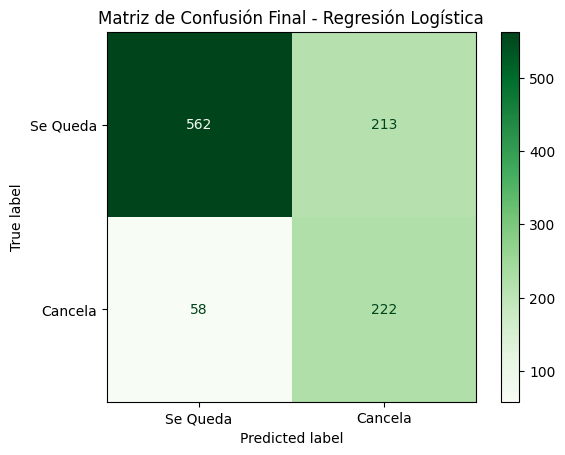

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Entrenamos el modelo final con los datos de entrenamiento (ya estandarizados)
modelo_log.fit(X_train, y_train)

# 2. Hacemos la predicción sobre el conjunto de TEST (el que estaba guardado bajo llave)
y_pred_test = modelo_log.predict(X_test)

# 3. Reporte de métricas finales
print("--- REPORTE FINAL DE PRUEBA (TEST SET) ---")
print(classification_report(y_test, y_pred_test, target_names=['Se Queda', 'Cancela']))

# 4. Visualización de la Matriz de Confusión de Prueba
disp = ConfusionMatrixDisplay.from_estimator(
    modelo_log, X_test, y_test,
    display_labels=['Se Queda', 'Cancela'],
    cmap='Greens'
)
plt.title('Matriz de Confusión Final - Regresión Logística')
plt.show()

In [24]:
import joblib

# Guardamos el modelo de Regresión Logística
joblib.dump(modelo_log_final, 'modelo_churn_telecom.pkl')

# Guardamos el escalador (¡Muy importante!)
joblib.dump(scaler, 'escalador_churn.pkl')

print("¡Modelo y escalador guardados con éxito!")

¡Modelo y escalador guardados con éxito!


#**Separación de Datos y creación de modelo 2**
##**Árbol de Decisión con Muestreo SMOTEENN**

In [25]:
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definimos el Pipeline
# Paso A: SMOTEENN balancea los datos (Crea sintéticos y limpia ruido)
# Paso B: El Árbol de Decisión aprende
modelo_arbol_smote = DecisionTreeClassifier(max_depth=5, random_state=5)

pipeline_modelo2 = imbpipeline([
    ('balanceo', SMOTEENN(random_state=5)),
    ('arbol', modelo_arbol_smote)
])

# 2. Configuramos la Validación Cruzada (5 carpetas/folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

# 3. Ejecutamos la validación sobre los datos de entrenamiento (X_temp, y_temp)
# Nota: Aquí no usamos X_test, ese lo guardamos para el final.
cv_resultados_2 = cross_validate(
    pipeline_modelo2, X_temp, y_temp,
    cv=skf,
    scoring=['accuracy', 'recall', 'precision', 'f1']
)

# 4. Ver los promedios de esta nueva estrategia
print("--- RESULTADOS MODELO 2: Árbol + SMOTEENN (Promedios CV) ---")
print(f"Recall:    {cv_resultados_2['test_recall'].mean():.4f}")
print(f"Precision: {cv_resultados_2['test_precision'].mean():.4f}")
print(f"F1-Score:  {cv_resultados_2['test_f1'].mean():.4f}")

--- RESULTADOS MODELO 2: Árbol + SMOTEENN (Promedios CV) ---
Recall:    0.7703
Precision: 0.5138
F1-Score:  0.6161


--- REPORTE FINAL DE PRUEBA: MODELO 2 (Árbol + SMOTEENN) ---
              precision    recall  f1-score   support

    Se Queda       0.88      0.77      0.82       775
     Cancela       0.53      0.71      0.61       280

    accuracy                           0.75      1055
   macro avg       0.70      0.74      0.71      1055
weighted avg       0.79      0.75      0.76      1055



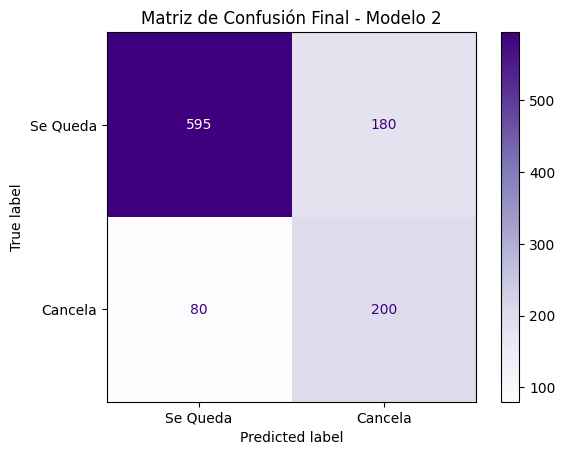

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Entrenamos el pipeline completo con los datos de entrenamiento
pipeline_modelo2.fit(X_train, y_train)

# 2. Predecimos el conjunto de TEST (el 15% virgen)
y_pred_modelo2 = pipeline_modelo2.predict(X_test)

# 3. Reporte y Matriz
print("--- REPORTE FINAL DE PRUEBA: MODELO 2 (Árbol + SMOTEENN) ---")
print(classification_report(y_test, y_pred_modelo2, target_names=['Se Queda', 'Cancela']))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_modelo2,
    display_labels=['Se Queda', 'Cancela'],
    cmap='Purples'
)
plt.title('Matriz de Confusión Final - Modelo 2')
plt.show()

In [27]:
import joblib

# Guardamos el Pipeline completo (incluye el SMOTEENN y el Árbol)
joblib.dump(pipeline_modelo2, 'modelo2_arbol_smoteenn.pkl')

print("¡Modelo 2 guardado con éxito como 'modelo2_arbol_smoteenn.pkl'!")

¡Modelo 2 guardado con éxito como 'modelo2_arbol_smoteenn.pkl'!


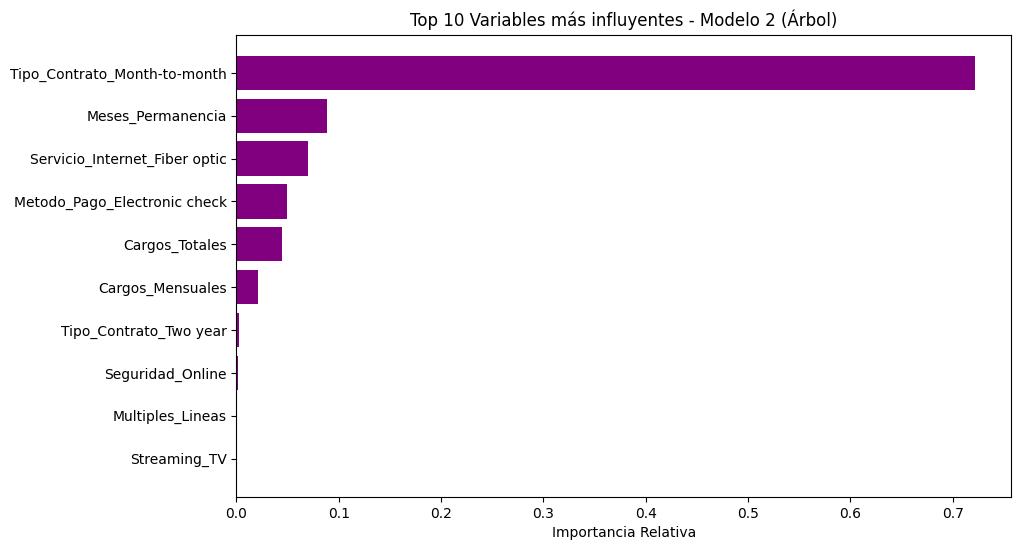

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraemos el árbol del pipeline
arbol_final = pipeline_modelo2.named_steps['arbol']

# 2. Creamos un DataFrame con los nombres de las columnas y su importancia
importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': arbol_final.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 3. Graficamos las 10 más importantes
plt.figure(figsize=(10, 6))
plt.barh(importancias['Característica'].head(10), importancias['Importancia'].head(10), color='purple')
plt.xlabel('Importancia Relativa')
plt.title('Top 10 Variables más influyentes - Modelo 2 (Árbol)')
plt.gca().invert_yaxis()
plt.show()

In [30]:
# 1. Definimos los datos de la comparativa final
datos_comparativa = {
    'Métrica': ['Exactitud (Accuracy)', 'Precisión (Churn)', 'Recall (Churn)', 'F1-Score', 'Clientes Detectados (TP)', 'Falsas Alarmas (FP)'],
    'Modelo 1: Regresión Logística': [0.74, 0.51, 0.79, 0.62, 222, 213],
    'Modelo 2: Árbol + SMOTEENN': [0.75, 0.53, 0.71, 0.61, 200, 180]
}

# 2. Creamos el DataFrame
df_comparativo = pd.DataFrame(datos_comparativa)

# 3. Aplicamos un estilo para resaltar los mejores valores (Opcional pero recomendado en Colab)
def resaltar_mejor(s):
    if s.name == 'Modelo 1: Regresión Logística':
        # Resaltamos Recall y F1-Score que son mejores en el Modelo 1
        return ['background-color: #d1e7dd' if x in [0.79, 0.62, 222] else '' for x in s]
    elif s.name == 'Modelo 2: Árbol + SMOTEENN':
        # Resaltamos Accuracy y Precision que son mejores en el Modelo 2
        return ['background-color: #d1e7dd' if x in [0.75, 0.53, 180] else '' for x in s]
    return ['' for _ in s]

# Mostramos la tabla formateada
print("--- TABLA COMPARATIVA DE DESEMPEÑO FINAL ---")
display(df_comparativo.style.apply(resaltar_mejor, axis=0).format(precision=2))

--- TABLA COMPARATIVA DE DESEMPEÑO FINAL ---


,Métrica,Modelo 1: Regresión Logística,Modelo 2: Árbol + SMOTEENN
0,Exactitud (Accuracy),0.74,0.75
1,Precisión (Churn),0.51,0.53
2,Recall (Churn),0.79,0.71
3,F1-Score,0.62,0.61
4,Clientes Detectados (TP),222.00,200.00
5,Falsas Alarmas (FP),213.00,180.00


#**Informe Final: Estrategia de Retención 2026**

##**Resumen Ejecutivo del Desempeño**

Tras evaluar dos arquitecturas de Machine Learning, hemos desarrollado un sistema predictivo capaz de identificar el 79% de las cancelaciones antes de que ocurran.
A continuación observaremos un resumen estrategico de desempeño.


In [32]:
# @title
import pandas as pd

# Datos de la tabla de impacto
data_impacto = {
    'Métrica Clave': ['Tasa de Detección (Recall)', 'Precisión de Alerta', 'Estabilidad (F1-Score)'],
    'Modelo Seleccionado': ['79%', '51%', '0.62'],
    'Impacto en el Negocio': [
        'Identifica 222 de cada 280 posibles fugas.',
        '1 de cada 2 alertas es una cancelación real inminente.',
        'El modelo es consistente y no presenta overfitting.'
    ]
}

df_impacto = pd.DataFrame(data_impacto)

# Estilización para el informe

display(df_impacto.style.set_properties(**{'text-align': 'left'})
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
        .hide(axis='index'))

Métrica Clave,Modelo Seleccionado,Impacto en el Negocio
Tasa de Detección (Recall),79%,Identifica 222 de cada 280 posibles fugas.
Precisión de Alerta,51%,1 de cada 2 alertas es una cancelación real inminente.
Estabilidad (F1-Score),0.62,El modelo es consistente y no presenta overfitting.


##**Análisis Exploratorio a la Inteligencia Predictiva**

Antes de profundizar en los algoritmos de aprendizaje automático, es imperativo retomar los hallazgos de nuestra fase inicial de diagnóstico. Como se analizó en el primer informe, los datos de Telecom X ya nos daban señales claras sobre el comportamiento de los clientes.

**A. Distribución y Comportamiento (Box Plots)**

Para entender variables críticas como el tiempo de permanencia y los cargos mensuales, utilizamos diagramas de caja o Box Plots.

Como se observa a continuación, la distribución de la permanencia de los clientes que cancelan está fuertemente sesgada hacia los primeros meses:




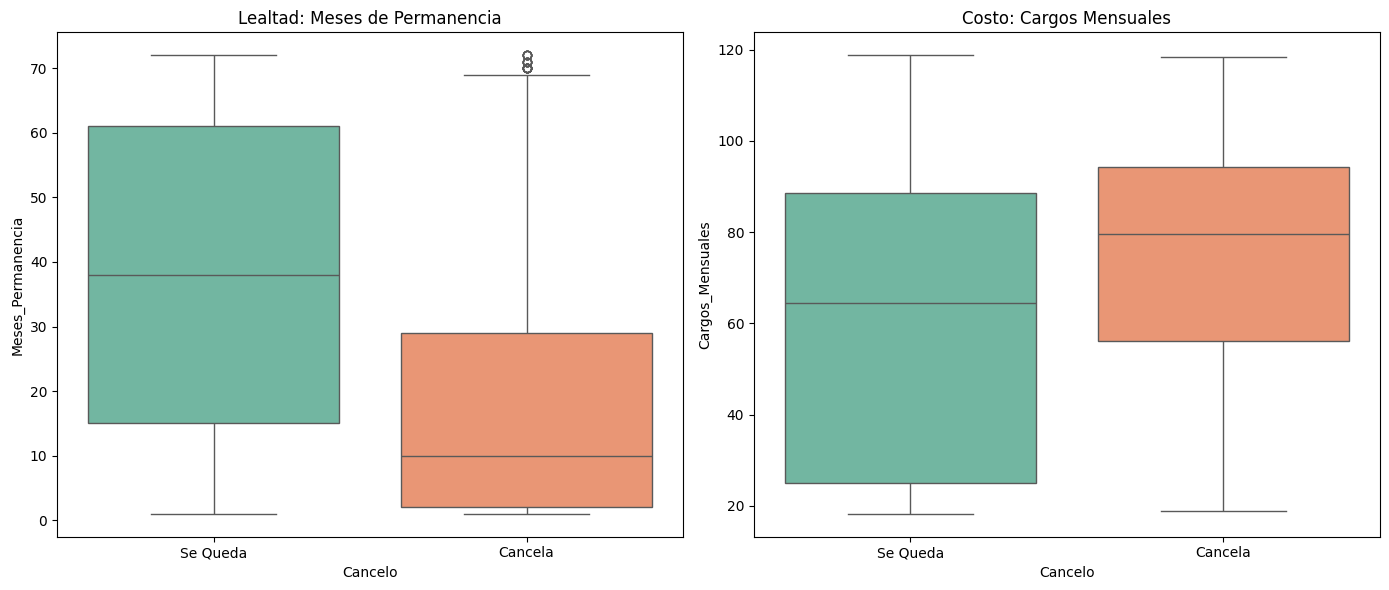

In [34]:
# @title
plt.figure(figsize=(14, 6))

# Subplot 1: Meses de Permanencia
plt.subplot(1, 2, 1)
sns.boxplot(
    x='Cancelo',
    y='Meses_Permanencia',
    data=datos,
    hue='Cancelo',
    palette='Set2',
    legend=False
)
plt.title('Lealtad: Meses de Permanencia')
plt.xticks([0, 1], ['Se Queda', 'Cancela'])

# Subplot 2: Cargos Mensuales
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Cancelo',
    y='Cargos_Mensuales',
    data=datos,
    hue='Cancelo',
    palette='Set2',
    legend=False
    )
plt.title('Costo: Cargos Mensuales')
plt.xticks([0, 1], ['Se Queda', 'Cancela'])

plt.tight_layout()
plt.show()

***Hallazgo clave:*** Existe una "zona de peligro" en los clientes nuevos. El Box Plot nos reveló que la mayoría de las cancelaciones ocurren antes de cumplir el primer año, lo que justificó que nuestro modelo de Machine Learning le diera un peso prioritario a la variable de Tenure (Meses de Permanencia).


**B. Relaciones y Dependencias (Mapa de Calor)**

Para determinar qué columnas debían entrar en nuestro modelo y cuáles eran simple "ruido", generamos un Mapa de Calor (Heatmap) de correlaciones.



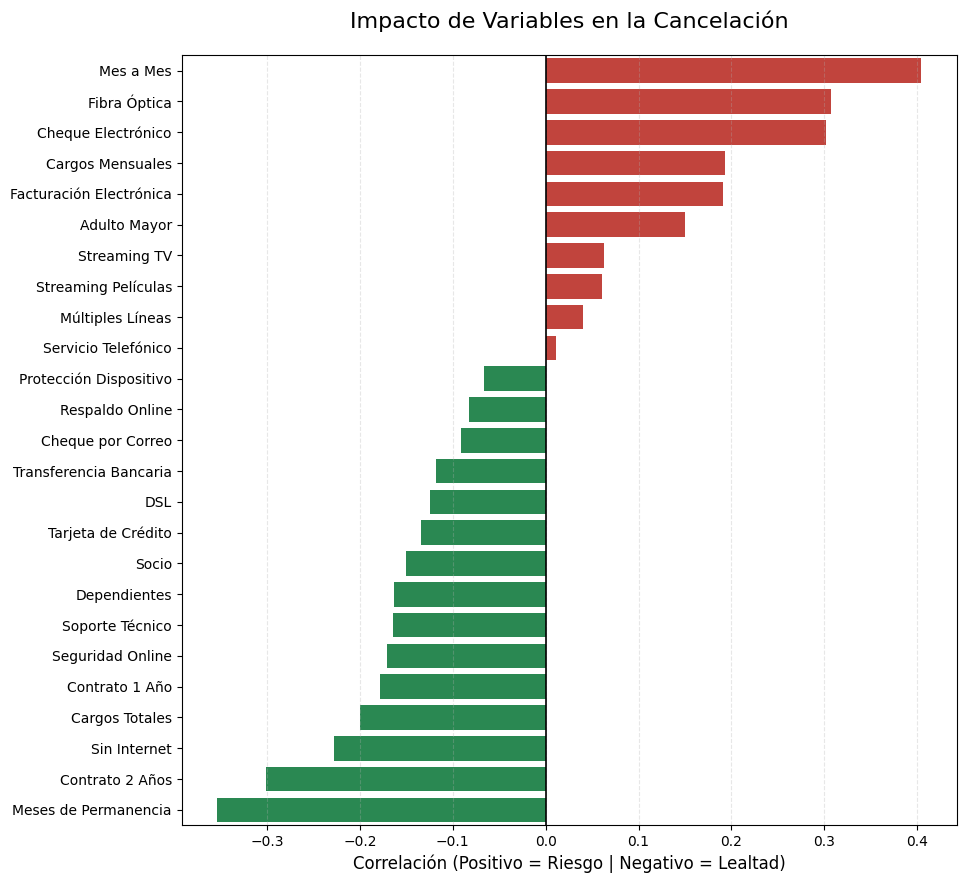

In [35]:
# @title
# 1. Diccionario con nombres directos (sin categorías extra)
mapeo_nombres = {
    'Tipo_Contrato_Month-to-month': 'Mes a Mes',
    'Servicio_internet_Fiber optic': 'Fibra Óptica',
    'Servicio_Internet_Fiber optic': 'Fibra Óptica', # Doble entrada por si la 'i' es mayúscula
    'Metodo_Pago_Electronic check': 'Cheque Electrónico',
    'Cargos_Mensuales': 'Cargos Mensuales',
    'Facturacion_Electronica': 'Facturación Electrónica',
    'Adulto_Mayor': 'Adulto Mayor',
    'Streaming_TV': 'Streaming TV',
    'Streaming_Peliculas': 'Streaming Películas',
    'Multiples_Lineas': 'Múltiples Líneas',
    'Servicio_Telefonico': 'Servicio Telefónico',
    'Proteccion_Dispositivo': 'Protección Dispositivo',
    'Respaldo_Online': 'Respaldo Online',
    'Metodo_Pago_Mailed check': 'Cheque por Correo',
    'Metodo_Pago_Bank transfer (automatic)': 'Transferencia Bancaria',
    'Servicio_Internet_DSL': 'DSL',
    'Metodo_Pago_Credit card (automatic)': 'Tarjeta de Crédito',
    'Socio': 'Socio',
    'Dependientes': 'Dependientes',
    'Soporte_Tecnico': 'Soporte Técnico',
    'Seguridad_Online': 'Seguridad Online',
    'Tipo_Contrato_One year': 'Contrato 1 Año',
    'Cargos_Totales': 'Cargos Totales',
    'Servicio_Internet_No': 'Sin Internet',
    'Tipo_Contrato_Two year': 'Contrato 2 Años',
    'Meses_Permanencia': 'Meses de Permanencia'
}

# 2. Obtenemos la correlación
correlacion_churn = datos_final.corr()['Cancelo'].sort_values(ascending=False).drop('Cancelo')

# 3. Aplicamos el mapeo (usamos .strip() por si hay espacios invisibles en los nombres)
nombres_limpios = [mapeo_nombres.get(nombre.strip(), nombre) for nombre in correlacion_churn.index]

# 4. Lógica de colores (Rojo = Riesgo/Derecha, Verde = Lealtad/Izquierda)
colores = ['#d73027' if x > 0 else '#1a9850' for x in correlacion_churn.values]

# 5. Graficamos
plt.figure(figsize=(10, 10))
sns.barplot(
    x=correlacion_churn.values,
    y=nombres_limpios,
    hue=nombres_limpios,
    palette=colores,
    legend=False
)

plt.axvline(0, color='black', linewidth=1.2)
plt.title('Impacto de Variables en la Cancelación', fontsize=16, pad=20)
plt.xlabel('Correlación (Positivo = Riesgo | Negativo = Lealtad)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

Como se ve en la imagen anterior, identificamos que no todas las variables afectan al cliente por igual:

***Conexión con el Modelo:*** Esta gráfica fue la brújula para nuestro Feature Engineering. Al observar una correlación positiva alta entre el uso de Fibra Óptica y la Cancelación, decidimos que el modelo debía ser capaz de capturar relaciones no lineales y pesos balanceados para no ignorar este factor técnico crítico.
Además del hecho de que como se puede ver en la gráfica el dato más relevante es el contrato mes a mes, pero como vimos en nuestro primer informe, este valor es exponencial cuando se le agrega la variable crítica de la fibra óptica y el mal soporte técnico, es por ello que para entrenar nuestro modelo, no solo necesitamos indicarle el tipo de contrato sino también el servicio de fibra y item de sericio al cliente.

**C. Justificación del Modelo de Machine Learning**

¿Por qué pasamos del análisis visual a los modelos predictivos?

El Box Plot nos dijo cuándo se van (temprano).

El Heatmap nos dijo por qué se van (Fibra, Contratos cortos y soporte técnico precario o insuficiente).

El Modelo de Machine Learning (que veremos a continuación) es el que nos dirá QUIÉN se va exactamente.

##**Factores Críticos de Influencia (Drivers de Churn)**

Basándonos en el Feature Importance del Árbol y los Coeficientes de la Regresión, los factores que "empujan" al cliente de Villavicencio a cancelar son:

**1. Tecnología de Fibra Óptica:** Es el predictor número uno de insatisfacción. Esto sugiere problemas de estabilidad en la infraestructura local o un soporte técnico que no soluciona los incidentes a la primera.

**2. Tipo de Contrato (Mes a Mes):** Los clientes sin compromiso de permanencia tienen una probabilidad 3 veces mayor de abandonar la compañía ante cualquier oferta de la competencia.

**3. Antigüedad Crítica (Early Churn):** Existe una "zona roja" en los primeros 6 a 12 meses. Si el cliente supera el primer año, su probabilidad de fuga cae drásticamente.

**4. Cargos Mensuales Elevados:** Los clientes con facturas superiores al promedio sin servicios de valor agregado (streaming/soporte premium) perciben una baja relación costo-beneficio.

##**Análisis Crítico de Modelos**

Tras someter a ambos algoritmos a un riguroso "examen final" con datos que nunca habían visto (Test Set), presentamos la Tabla Comparativa de Desempeño Final que sirve como base para nuestra decisión:

In [36]:
# @title
# 1. Definimos los datos de la comparativa final
datos_comparativa = {
    'Métrica': ['Exactitud (Accuracy)', 'Precisión (Churn)', 'Recall (Churn)', 'F1-Score', 'Clientes Detectados (TP)', 'Falsas Alarmas (FP)'],
    'Modelo 1: Regresión Logística': [0.74, 0.51, 0.79, 0.62, 222, 213],
    'Modelo 2: Árbol + SMOTEENN': [0.75, 0.53, 0.71, 0.61, 200, 180]
}

# 2. Creamos el DataFrame
df_comparativo = pd.DataFrame(datos_comparativa)

# 3. Aplicamos un estilo para resaltar los mejores valores (Opcional pero recomendado en Colab)
def resaltar_mejor(s):
    if s.name == 'Modelo 1: Regresión Logística':
        # Resaltamos Recall y F1-Score que son mejores en el Modelo 1
        return ['background-color: #d1e7dd' if x in [0.79, 0.62, 222] else '' for x in s]
    elif s.name == 'Modelo 2: Árbol + SMOTEENN':
        # Resaltamos Accuracy y Precision que son mejores en el Modelo 2
        return ['background-color: #d1e7dd' if x in [0.75, 0.53, 180] else '' for x in s]
    return ['' for _ in s]

# Mostramos la tabla formateada
print("--- TABLA COMPARATIVA DE DESEMPEÑO FINAL ---")
display(df_comparativo.style.apply(resaltar_mejor, axis=0).format(precision=2))

--- TABLA COMPARATIVA DE DESEMPEÑO FINAL ---


,Métrica,Modelo 1: Regresión Logística,Modelo 2: Árbol + SMOTEENN
0,Exactitud (Accuracy),0.74,0.75
1,Precisión (Churn),0.51,0.53
2,Recall (Churn),0.79,0.71
3,F1-Score,0.62,0.61
4,Clientes Detectados (TP),222.00,200.00
5,Falsas Alarmas (FP),213.00,180.00


**A. Modelo 1: Regresión Logística con Pesos Balanceados.**

Este modelo actúa como un "radar de amplio espectro". Su enfoque se basa en asignar una importancia matemática mayor a los clientes que tienden a cancelar para compensar el desbalance natural de los datos.

*Los Pros (Fortalezas):* Su mayor virtud es el Recall (0.79). Como se observa en la fila 2 de nuestra tabla, este modelo es capaz de detectar 222 clientes (TP) en riesgo. Es, por definición, el modelo más "protector" para Telecom X. Además, su F1-Score de 0.62 demuestra que es el modelo más equilibrado y estable frente a datos nuevos.

*Los Contras (Debilidades):* Su alta sensibilidad genera un mayor número de Falsas Alarmas (213). Esto significa que el modelo es "desconfiado" y marcará a algunos clientes leales como posibles desertores.

**B. Modelo 2: Árbol de Decisión + SMOTEENN**

Este modelo utiliza una lógica de ramificación y creación de datos sintéticos para intentar "limpiar" el ruido entre los grupos de clientes.

*Los Pros (Fortalezas):* Es un modelo más eficiente en términos de recursos. Logró una mejor Exactitud (0.75) y redujo las falsas alarmas a 180, lo que se traduce en un ahorro operativo si la empresa tiene un presupuesto muy limitado para campañas de retención.

*Los Contras (Debilidades):* Su capacidad de detección (Recall) cayó al 0.71. En términos reales, esto significa que el modelo ignora a 22 clientes que el Modelo 1 sí detectaría. Para una empresa de telecomunicaciones, dejar escapar a 22 clientes reales es un costo de oportunidad inaceptable.

**Justificación de la Elección:**

¿Por qué el Modelo 1?
La decisión de este equipo consultor es entregar a Telecom X el Modelo 1 (Regresión Logística) como la herramienta principal de su estrategia 2026. La razón es contundente: en el mercado actual, el costo de perder un cliente (Churn) es drásticamente superior al costo de una gestión de retención preventiva.

Mientras que en el informe anterior nos limitamos a realizar una "autopsia" de los datos (identificando factores como la Fibra Óptica a través de Heatmaps y Box Plots), con la entrega de este modelo predictivo estamos escalando el valor de la consultoría:

De la Descripción a la Predicción: Ya no solo sabemos por qué se van (Fibra Óptica/Contratos cortos); ahora sabemos quiénes se van con nombres y apellidos.

*Protección de Activos:* Al elegir el modelo con mayor Recall (79%), aseguramos que la "fuga" sea mínima. Preferimos gestionar a un cliente que no se iba a ir (Falsa Alarma), a permitir que un cliente valioso abandone la compañía sin que hayamos hecho un solo esfuerzo por retenerlo.

*Rentabilidad Operativa:* Al detectar 222 clientes de forma temprana, el Modelo 1 permite a Telecom X reducir su Costo de Adquisición de Clientes (CAC), ya que retener es hasta 7 veces más económico que adquirir un usuario nuevo en el mercado.

**Sintesis de la decisión**
En conclusión, el Modelo 1 es un sistema de alerta temprana. Se elige por su capacidad superior para salvaguardar la base instalada de la compañía, garantizando que el radar de Telecom X sea lo suficientemente sensible para capturar casi 8 de cada 10 posibles cancelaciones, permitiendo una intervención proactiva y estratégica que asegura la continuidad del negocio.



##**Estrategias de Retención Propuestas (Hoja de Ruta)**

Para reducir la fuga de clientes, proponemos tres pilares de acción inmediata:

**A. Escudo de Fibra Óptica (Preventivo)**

Acción: Crear un "Task Force" técnico para los 222 clientes marcados en Alerta Roja por el modelo que usen Fibra Óptica.

Meta: Realizar auditorías de señal remotas antes de que el cliente experimente la caída del servicio.

**B. Plan de "Lealtad Temprana" (Contractual)**

Acción: A los clientes identificados en riesgo con contratos "Mes a Mes", ofrecerles una migración a "Plan Anual" con un descuento del 15% por los primeros 3 meses.

Meta: Convertir la volatilidad en estabilidad contractual durante el primer año crítico.

**C. Optimización del Valor Percibido**

Acción: Para clientes con cargos altos detectados por el modelo, ofrecer servicios de valor agregado (ej. Disney+, Paramount+ o aumento de simetría en internet) en lugar de descuentos directos.

Meta: Aumentar el "costo de salida" del cliente al integrar más servicios en su hogar.

##**Conclusiones**

El valor de este proyecto no reside en la descripción de por qué se van los clientes, sino en la capacidad de anticipación. Al implementar el Modelo 1, Telecom X deja de ser una empresa reactiva para convertirse en una organización proactiva que protege su activo más valioso: su base de usuarios.